# Assignment 1: Task D.3 - CheckList
### Does adding a security system prompt to a model reduce its linguistic performance

The basic structures are taken from the checklist.ipynb notebook.

**Test Types:**
1.  **Minimum Functionality Tests (MFT):** Simple examples designed to test specific capabilities with an expected outcome (e.g., basic synonyms should result in a 'duplicate' prediction).
2.  **Invariance Tests (INV):** Applying meaning-preserving perturbations (changes) to an input and checking if the model's prediction *stays the same* (e.g., adding punctuation shouldn't change the duplicate status).
3.  **Directional Expectation Tests (DIR):** Applying perturbations that *should* change the output in a specific way and checking if the model behaves as expected (e.g., adding negation to one question should change the status from 'duplicate' to 'not duplicate').

## 1. Setup: Install Libraries and Load Model


In [1]:
# Uncomment the line below and run this cell if you haven't installed these libraries
# !pip install torch transformers matplotlib

import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import matplotlib.pyplot as plt
import warnings
import time
import re

# Suppress specific warnings if needed (optional)
warnings.filterwarnings("ignore", category=UserWarning, module='transformers')

# --- Model Selection ---
# We'll use a RoBERTa model fine-tuned specifically on the QQP dataset.
MODEL_NAME = "JeremiahZ/roberta-base-qqp"

# You can change this to any other model name from Hugging Face Model Hub:
# MODEL_NAME = "textattack/bert-base-uncased-QQP" # fine-tuned model
# MODEL_NAME = "FacebookAI/roberta-base"
# MODEL_NAME = "textattack/distilbert-base-uncased-QQP"
# MODEL_NAME = "google-bert/bert-base-uncased"

print(f"[{time.strftime('%H:%M:%S')}] Loading tokenizer: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"[{time.strftime('%H:%M:%S')}] Tokenizer loaded.")

print(f"[{time.strftime('%H:%M:%S')}] Loading model: {MODEL_NAME}...")
# This might take a minute or two depending on your internet connection and machine.
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME)
print(f"[{time.strftime('%H:%M:%S')}] Model loaded.")
model.eval()

print("\nSetup complete. Model and tokenizer are ready!")

[13:05:44] Loading tokenizer: JeremiahZ/roberta-base-qqp...


config.json:   0%|          | 0.00/900 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/380 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

[13:05:49] Tokenizer loaded.
[13:05:49] Loading model: JeremiahZ/roberta-base-qqp...


pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: JeremiahZ/roberta-base-qqp
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[13:06:08] Model loaded.

Setup complete. Model and tokenizer are ready!


## 2. Prediction Function

We need a function that takes two questions and uses our loaded model to predict whether they are duplicates. The QQP task is typically framed as a binary classification:
*   **Label 0:** The questions are *not* duplicates.
*   **Label 1:** The questions *are* duplicates.

Our function will:
1.  **Tokenize** the input questions pair using the loaded tokenizer.
2.  Feed the tokenized input into the model.
3.  Get the **logits** (raw scores) from the model.
4.  Convert logits to **probabilities** using the Softmax function.
5.  Check the probability of the 'duplicate' class (usually index 1).
6.  Return label `1` if the duplicate probability is above a certain threshold (e.g., 0.5), otherwise return `0`.

In [2]:
def predict_qqp_label(question1, question2, threshold=0.5):
    """
    Uses the loaded model to predict if two questions are duplicates.
    Returns 1 (duplicate) if prediction probability >= threshold, else 0.
    """
    # Tokenize the pair of questions
    inputs = tokenizer(question1, question2, return_tensors='pt', truncation=True, max_length=512)

    # Make prediction
    with torch.no_grad(): # We don't need gradients during inference
        outputs = model(**inputs)
        logits = outputs.logits

    # Convert logits to probabilities
    probs = F.softmax(logits, dim=1)

    # The model structure puts [prob_not_duplicate, prob_duplicate]
    # We access the probability of the 'duplicate' class (index 1)
    dup_prob = probs[0, 1].item() # .item() gets the Python number from the tensor

    # Return the label based on the threshold
    return 1 if dup_prob >= threshold else 0

# Let's test the prediction function with a simple example:
q1_test = "How can I learn coding?"
q2_test_dup = "What are ways I can learn to code?"
q2_test_not_dup = "What is the capital of France?"

pred_dup = predict_qqp_label(q1_test, q2_test_dup, threshold=0.5)
pred_not_dup = predict_qqp_label(q1_test, q2_test_not_dup, threshold=0.5)

print(f"Prediction for likely duplicates ('{q1_test}' vs '{q2_test_dup}'): {pred_dup}")
print(f"Prediction for non-duplicates ('{q1_test}' vs '{q2_test_not_dup}'): {pred_not_dup}")

Prediction for likely duplicates ('How can I learn coding?' vs 'What are ways I can learn to code?'): 1
Prediction for non-duplicates ('How can I learn coding?' vs 'What is the capital of France?'): 0


## 3. Generic Test Functions (MFT, INV, DIR)

Now, let's define the functions that will run our tests. These functions are generic and will take lists of test cases and specific 'perturbation' or 'expectation' functions as input.

*   `run_mft`: Takes pairs of questions and their expected labels. Records a failure if the model's prediction doesn't match the expectation.
*   `run_inv`: Takes pairs of questions. It first gets the original prediction. Then, it applies a `perturb_fn` [perturbation function] (which *shouldn't* change the meaning) and gets the new prediction. Records a failure if the original and new predictions differ.
*   `run_dir`: Takes pairs of questions. It gets the original prediction. It applies a `perturb_fn` (which *should* change the meaning/label). It uses an `expected_fn` [expected function] to determine what the *new* label should be based on the *original* label. Records a failure if the model's prediction on the perturbed input doesn't match the expected new label.

In [3]:
def run_mft(test_cases):
    """
    MFT (Minimum Functionality Test): Expects model prediction to match expected_label.
    test_cases: list of (q1, q2, expected_label)
    Returns: list of failures, where each failure is ((q1, q2), expected, predicted)
    """
    failures = []
    print(f"  Running MFT with {len(test_cases)} cases...")
    for i, (q1, q2, expected) in enumerate(test_cases):
        try:
            pred = predict_qqp_label(q1, q2)
            if pred != expected:
                failures.append(((q1, q2), expected, pred))
        except Exception as e:
            print(f"    Error during MFT prediction for case: {(q1, q2)}. Error: {e}")
        # Print progress
        # if (i + 1) % 5 == 0: print(f"    Processed {i+1}/{len(test_cases)}")
    print(f"  MFT completed. Found {len(failures)} failures out of {len(test_cases)} cases.")
    return failures

def run_inv(test_cases, perturb_fn):
    """
    INV (Invariance Test): Expects model prediction to remain the same after perturbation.
    test_cases: list of (q1, q2)
    perturb_fn: function(q1, q2) -> (perturbed_q1, perturbed_q2)
    Returns: list of failures, where each failure is ((q1, q2), orig_label, (q1p, q2p), new_label)
    """
    failures = []
    print(f"  Running INV with {len(test_cases)} cases...")
    for i, (q1, q2) in enumerate(test_cases):
        try:
            original_label = predict_qqp_label(q1, q2)
            q1p, q2p = perturb_fn(q1, q2)
            new_label = predict_qqp_label(q1p, q2p)
            if new_label != original_label:
                failures.append(((q1, q2), original_label, (q1p, q2p), new_label))
        except Exception as e:
            print(f"    Error during INV perturbation or prediction for case: {(q1, q2)}. Error: {e}")
        # Optional: Print progress
        # if (i + 1) % 5 == 0: print(f"    Processed {i+1}/{len(test_cases)}")
    print(f"  INV completed. Found {len(failures)} failures out of {len(test_cases)} cases.")
    return failures

def run_dir(test_cases, perturb_fn, expected_fn):
    """
    DIR (Directional Expectation Test): Expects model prediction to change predictably after perturbation.
    test_cases: list of (q1, q2)
    perturb_fn: function(q1, q2) -> (perturbed_q1, perturbed_q2)
    expected_fn: function(original_label) -> expected_new_label (can return None if expectation is undefined)
    Returns: list of failures, where each failure is ((q1, q2), orig_label, (q1p, q2p), new_label, exp_label)
    """
    failures = []
    print(f"  Running DIR with {len(test_cases)} cases...")
    for i, (q1, q2) in enumerate(test_cases):
        try:
            orig_label = predict_qqp_label(q1, q2)
            q1p, q2p = perturb_fn(q1, q2)
            new_label = predict_qqp_label(q1p, q2p)
            exp_label = expected_fn(orig_label)

            # We only record a failure if the expectation was defined (not None)
            # and the model's prediction did not match the expectation.
            if exp_label is not None and new_label != exp_label:
                failures.append(((q1, q2), orig_label, (q1p, q2p), new_label, exp_label))
        except Exception as e:
            print(f"    Error during DIR perturbation or prediction for case: {(q1, q2)}. Error: {e}")
        # Print progress
        # if (i + 1) % 5 == 0: print(f"    Processed {i+1}/{len(test_cases)}")
    print(f"  DIR completed. Found {len(failures)} failures out of {len(test_cases)} potential directional tests.")
    return failures

## 4. Defining Capability Tests

We define a new linguistic characteristics:
- **Numerical Reasoning** Since we saw Roberta struggle heavily with the numerical predictions in the task before, we thought was a good problem to investigate further.
- **Logical and Commonsense** Maybe the model also struggles generally to understand commonsense logic and that's why it failed the predictions. Therefore the logical/commonsense from the notebook seemed like a good addition.
 
We define tests for all test-types (MFT, INV, DIR) below. The implementations follows the structure from the notebook to ensure consistent handling.

Numerical Reasoning:

In [8]:
print("Defining Numerical Reasoning tests...")

# --- 1) MFT: Minimum Functionality Tests ---
mft_numeric = [
    # Expected = 1 (Duplicates - same value, different format/unit)
    ("How can I earn 100 dollars?", "How can I make one hundred dollars?", 1),
    ("How many hours are in a day?", "How many minutes are in 24 hours?", 1),
    ("Is a dozen eggs enough for a cake?", "Are 12 eggs sufficient for a cake?", 1),
    ("What happened in 1990?", "What events occurred in the year nineteen ninety?", 1),
    # Expected = 0 (Non-duplicates - different values)
    ("How to lose 5kg in a week?", "How to lose 50kg in a week?", 0),
    ("Is it safe to drive at 60 mph?", "Is it safe to drive at 100 mph?", 0),
    ("What is 10 + 10?", "What is 10 + 20?", 0),
    ("How many people live in NYC?", "How many people live in the US?", 0),
]

# --- 2) INV: Invariance Tests ---
inv_numeric = [
    ("How to save 1000 dollars fast?", "What is the quickest way to save 1000 dollars?"),
    ("Is 5 percent a good interest rate?", "Is 5% a good interest rate?"),
    ("What happened in the year 2024?", "Can you tell me the events of 2024?"),
]

def numeric_inv_perturb_fn(q1, q2):
    """
    Perturbation: Change '1000' to '1,000' or '5' to '5.0'.
    This should not change the duplicate status.
    """
    def format_num(text):
        # Simple regex to add .0 to integers or add commas to 4+ digit numbers
        text = re.sub(r'\b(\d{4,})\b', lambda x: f"{int(x.group(1)):,}", text)
        text = re.sub(r'\b(\d{1,3})\b', lambda x: f"{x.group(1)}.0", text)
        return text

    return (format_num(q1), format_num(q2))

# --- 3) DIR: Directional Expectation Tests ---
dir_numeric = [
    ("How do I make 50 dollars a day?", "What are ways to earn $50 daily?"), # Expect 1 -> 0
    ("What are 10 ways to cook eggs?", "Can you give me ten recipes for eggs?"), # Expect 1 -> 0
    ("Is it healthy to sleep 8 hours?", "Is sleeping for eight hours good for health?"), # Expect 1 -> 0
]

def numeric_dir_perturb_fn(q1, q2):
    """
    Perturbation: Find a number in q1 and change its value.
    This should break the semantic equivalence.
    """
    # Find digits and increment the first one found
    match = re.search(r'\d+', q1)
    if match:
        old_val = match.group()
        new_val = str(int(old_val) + 5) # Change value significantly
        q1p = q1[:match.start()] + new_val + q1[match.end():]
    else:
        q1p = q1 + " (but specifically for 100 items)" # Fallback

    return (q1p, q2)

def numeric_expected_fn(old_label):
    # If they were duplicates, changing the number makes them non-duplicates.
    return 0

Defining Numerical Reasoning tests...


Logic and Commonsense:

In [9]:
print("Defining Logic/Commonsense tests...")
# 1) MFT: Test basic logical equivalence or commonsense
mft_logic = [
    # Expected = 1 (Logically/Commonsensically equivalent)
    ("Which is bigger: an elephant or a mouse?", "Is a mouse smaller than an elephant?", 1),
    ("Is 10 greater than 5?", "Is 5 less than 10?", 1),
    ("If it rains, the ground gets wet. It rained.", "Since it rained, is the ground wet?", 1), # Simple Modus Ponens
    ("Is water wet?", "Does H2O have the property of wetness?", 1), # Commonsense
    ("Are all squares rectangles?", "Does being a square imply being a rectangle?", 1),
    # Expected = 0 (Logically/Commonsensically different or contradictory)
    ("Is 8 larger than 3?", "Is 3 larger than 8?", 0),
    ("If A implies B, does B imply A?", "Is the converse always true?", 0), # Logical fallacy
    ("Are all birds animals?", "Are all animals birds?", 0), # Category error
    ("Can humans breathe underwater without equipment?", "Is it possible for people to swim underwater indefinitely?", 0), # Commonsense violation
]

# 2) INV: Add logical connectives or qualifiers that don't change the core logic
inv_logic = [
    ("Is 10 greater than 5?", "Is 5 less than 10?"),
    ("Is water H2O?", "Is the chemical formula for water H2O?"),
    ("Are elephants mammals?", "Do elephants belong to the class Mammalia?"),
    ("If you drop a ball, will it fall?", "Does gravity cause a dropped ball to fall?"),
]
def logic_inv_perturb_fn(q1, q2):
    # Add phrases like "necessarily", "generally", "Is it true that" which shouldn't alter the basic truth value.
    q1p = "Is it necessarily true that " + q1[3:] if q1.startswith("Is ") else q1 # Crude prefix add
    q2p = q2.replace("?", " generally?") if "?" in q2 else q2 + " generally"
    return (q1p, q2p)

# 3) DIR: Change the logical relationship (e.g., reverse comparison, negate premise), expecting 1 -> 0
dir_logic = [
    ("Is 8 larger than 3?", "Is three smaller than eight?"), # Expect 1 -> 0
    ("Is a square a rectangle?", "Does being a square imply rectangle properties?"), # Expect 1 -> 0
    ("If it's snowing, it must be cold.", "Does snowy weather indicate low temperatures?"), # Expect 1 -> 0
    ("Does smoking cause cancer?", "Is cancer caused by smoking?"), # Expect 1 -> 0 (causality)
]
def logic_dir_perturb_fn(q1, q2):
    # Reverse the comparison or logical relationship in the first question.
    if   " larger than "  in q1: q1p = q1.replace(" larger than ", " smaller than ", 1)
    elif " smaller than " in q1: q1p = q1.replace(" smaller than ", " larger than ", 1)
    elif " cause "        in q1: q1p = q1.replace(" cause ", " prevent ", 1) # Change relation
    elif " a square a rectangle"     in q1: q1p = q1.replace("rectangle", "circle") # Change category
    elif " snowing, it must be cold" in q1: q1p = q1.replace("cold", "hot") # Change consequence
    else:
        q1p = "Is it false that " + q1 # General negation as fallback
    return (q1p, q2)

def logic_expected_fn(old_label):
    # If the original pair was duplicate (1), changing the core logic should make it non-duplicate (0).
    return 0 if old_label == 1 else 0

Defining Logic/Commonsense tests...


## 5. Running the Tests

With all our test cases and helper functions defined, let's run them! We will store the results (failures and total counts for each test type) in a dictionary.

In [10]:
# Numerical Reasoning
print("\nTesting: Numerical Reasoning")
all_results = {}
all_results["Numeric_MFT"] = {"fails": run_mft(mft_numeric), "total": len(mft_numeric)}
all_results["Numeric_INV"] = {"fails": run_inv(inv_numeric, numeric_inv_perturb_fn), "total": len(inv_numeric)}
all_results["Numeric_DIR"] = {"fails": run_dir(dir_numeric, numeric_dir_perturb_fn, numeric_expected_fn), "total": len(dir_numeric)}

# Logical Consistency
print("\nTesting: Logic/Commonsense")
all_results["Logic_MFT"] = {"fails": run_mft(mft_logic), "total": len(mft_logic)}
all_results["Logic_INV"] = {"fails": run_inv(inv_logic, logic_inv_perturb_fn), "total": len(inv_logic)}
all_results["Logic_DIR"] = {"fails": run_dir(dir_logic, logic_dir_perturb_fn, logic_expected_fn), "total": len(dir_logic)}


Testing: Numerical Reasoning
  Running MFT with 8 cases...
  MFT completed. Found 3 failures out of 8 cases.
  Running INV with 3 cases...
  INV completed. Found 0 failures out of 3 cases.
  Running DIR with 3 cases...
  DIR completed. Found 1 failures out of 3 potential directional tests.

Testing: Logic/Commonsense
  Running MFT with 9 cases...
  MFT completed. Found 6 failures out of 9 cases.
  Running INV with 4 cases...
  INV completed. Found 1 failures out of 4 cases.
  Running DIR with 4 cases...
  DIR completed. Found 0 failures out of 4 potential directional tests.


## 6. Analyzing Results

Let's summarize the results. We'll calculate the failure rate for each test type (capability + MFT/INV/DIR) and display it in a table and a bar chart.

**Failure Rate = (Number of Failures / Total Test Cases) * 100**

A high failure rate for a specific test type suggests the model struggles with that particular capability or scenario.


         BEHAVIORAL TEST SUMMARY
Test Label         | Failures | Total | Fail Rate (%)
------------------------------------------------------------
Numeric_MFT        | 3        | 8     | 37.5        
Numeric_INV        | 0        | 3     | 0.0         
Numeric_DIR        | 1        | 3     | 33.3        
Logic_MFT          | 6        | 9     | 66.7        
Logic_INV          | 1        | 4     | 25.0        
Logic_DIR          | 0        | 4     | 0.0         

--- Generating Visualization ---


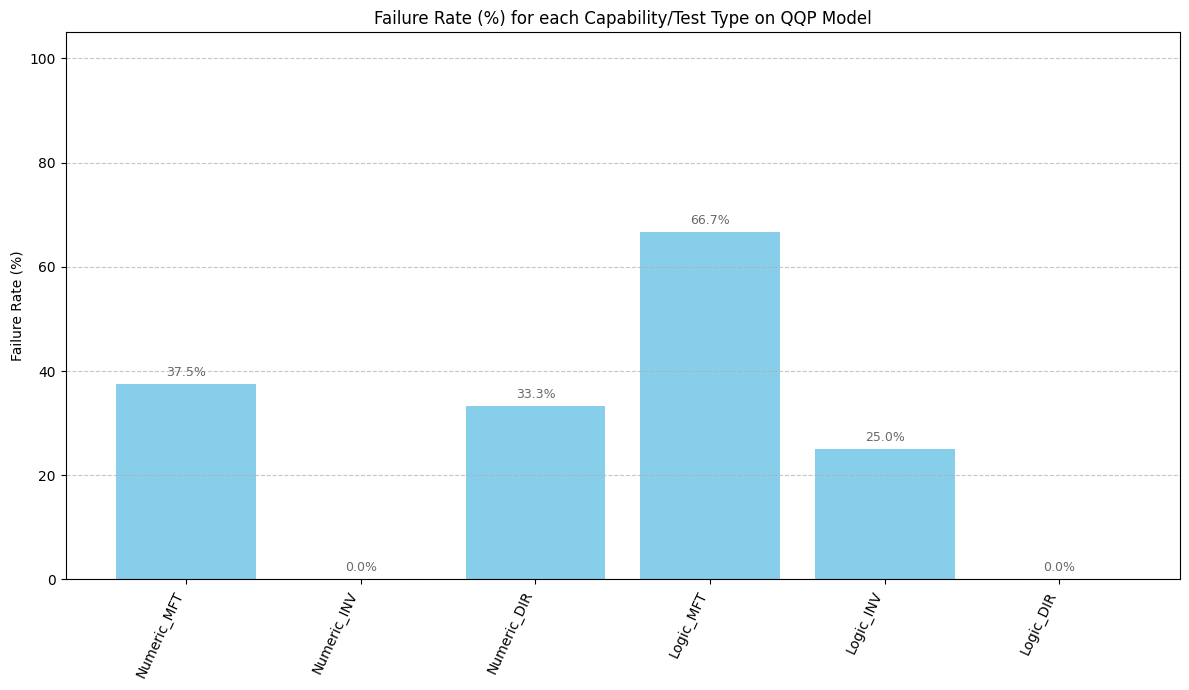

Visualization generated.


In [11]:
labels = list(all_results.keys())
fail_counts = [len(all_results[label]["fails"]) for label in labels]
total_counts = [all_results[label]["total"] for label in labels]
failure_rates = [
    round(fail_counts[i] / total_counts[i] * 100.0, 1) if total_counts[i] > 0 else 0
    for i in range(len(labels))
]

print("\n===========================================")
print("         BEHAVIORAL TEST SUMMARY")
print("===========================================")
print(f"{'Test Label':<18} | {'Failures':<8} | {'Total':<5} | {'Fail Rate (%)':<12}")
print("-" * 60)
for i, label in enumerate(labels):
    print(f"{label:<18} | {fail_counts[i]:<8} | {total_counts[i]:<5} | {failure_rates[i]:<12.1f}")
print("===========================================")

# --- Visualization ---
print("\n--- Generating Visualization ---")
try:
    plt.figure(figsize=(12, 7)) # Adjusted figure size for better label readability
    bars = plt.bar(labels, failure_rates, color='skyblue')
    plt.xticks(rotation=65, ha="right") # Rotate labels for clarity
    plt.title("Failure Rate (%) for each Capability/Test Type on QQP Model")
    plt.ylabel("Failure Rate (%)")
    plt.ylim(0, 105) # Set y-axis limit slightly above 100%

    # Add failure rate labels on top of bars
    for bar in bars:
        yval = bar.get_height()
        if yval >= 0: # Display label even for 0% failure rate
             plt.text(bar.get_x() + bar.get_width()/2.0, yval + 1, f'{yval:.1f}%', \
                      va='bottom', ha='center', fontsize=9, color='dimgray')

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout() # Adjust layout
    plt.show()
    print("Visualization generated.")
except Exception as e:
    print(f"Could not generate plot. Error: {e}")
    print("Ensure matplotlib is installed and working in your environment.")

## 7. Exploring Failures

Looking at aggregated failure rates is useful, but the real insights often come from examining the specific examples where the model failed. Why did it fail? Was the test case flawed? Or did the model misunderstand something fundamental?

Let's print the details of the failed test cases.

In [13]:
def print_failure_details(results):
    print("\n--- Failure Case Details ---")
    found_failures = False
    for label, result in results.items():
        fails = result["fails"]
        if fails:
            found_failures = True
            print(f"\n### Failures for {label} ({len(fails)}):")
            print("-" * (len(label) + 20))
            for i, item in enumerate(fails):
                print(f" Failure #{i+1}")
                if len(item) == 3: # MFT failure: ((q1, q2), expected, predicted)
                    (q1, q2), expected, predicted = item
                    print(f"  - Type: MFT")
                    print(f"  - Expected Label: {expected}, Model Predicted: {predicted}")
                    print(f"    Q1: {q1}")
                    print(f"    Q2: {q2}")
                elif len(item) == 4: # INV failure: ((q1, q2), orig_label, (q1p, q2p), new_label)
                    (q1, q2), orig_label, (q1p, q2p), new_label = item
                    print(f"  - Type: INV")
                    print(f"  - Original Label: {orig_label}, Perturbed Label: {new_label} (FAILED: Should have been {orig_label})")
                    print(f"    Original Q1:  {q1}")
                    print(f"    Original Q2:  {q2}")
                    print(f"    Perturbed Q1: {q1p}")
                    print(f"    Perturbed Q2: {q2p}")
                elif len(item) == 5: # DIR failure: ((q1, q2), orig_label, (q1p, q2p), new_label, exp_label)
                    (q1, q2), orig_label, (q1p, q2p), new_label, exp_label = item
                    print(f"  - Type: DIR")
                    print(f"  - Original Label: {orig_label}, Perturbed Label: {new_label}, Expected Perturbed Label: {exp_label} (FAILED)")
                    print(f"    Original Q1:  {q1}")
                    print(f"    Original Q2:  {q2}")
                    print(f"    Perturbed Q1: {q1p}")
                    print(f"    Perturbed Q2: {q2p}")
                print("-----") # Separator between failures
    if not found_failures:
        print("\nNo failures were recorded across all tests!")

# --- Uncomment the line below to print all failure details ---
print_failure_details(all_results)


--- Failure Case Details ---

### Failures for Numeric_MFT (3):
-------------------------------
 Failure #1
  - Type: MFT
  - Expected Label: 1, Model Predicted: 0
    Q1: How many hours are in a day?
    Q2: How many minutes are in 24 hours?
-----
 Failure #2
  - Type: MFT
  - Expected Label: 1, Model Predicted: 0
    Q1: What happened in 1990?
    Q2: What events occurred in the year nineteen ninety?
-----
 Failure #3
  - Type: MFT
  - Expected Label: 0, Model Predicted: 1
    Q1: How to lose 5kg in a week?
    Q2: How to lose 50kg in a week?
-----

### Failures for Numeric_DIR (1):
-------------------------------
 Failure #1
  - Type: DIR
  - Original Label: 1, Perturbed Label: 1, Expected Perturbed Label: 0 (FAILED)
    Original Q1:  What are 10 ways to cook eggs?
    Original Q2:  Can you give me ten recipes for eggs?
    Perturbed Q1: What are 15 ways to cook eggs?
    Perturbed Q2: Can you give me ten recipes for eggs?
-----

### Failures for Logic_MFT (6):
--------------------

## Error Analysis

For the error analysis we follow the basic structure from the lecture: We first look at individual instances and try to group them. Do some more data augmentation if necessary, develop hypotheses and then assess those. 

General Comments: 
Regarding the Logic answers, what seems odd in the results is that the model 
fails 66% of the *minimum* functionality tests, but passes the one we would expect
to be harder (DIR) with flying colors. Was one of the tests not well adjusted perhaps?

We have different numbers of testcases for many capabilities and that should influence 
how confident we are in the results of this test. Generally the number of samples
is for this experiment pretty low, so noise could always be a factor in the analysis. 

Observations and Schemas from individual instances: 
- Equality of numerical/alphabetically expressed numbers.

 Failure #2
  - Type: MFT
  - Expected Label: 1, Model Predicted: 0
    Q1: What happened in 1990?
    Q2: What events occurred in the year nineteen ninety?

- Less than/larger than. In general no understanding of numbers, their order -  Maybe it just represents them super similar all in latent space?

 Failure #1
  - Type: DIR
  - Original Label: 1, Perturbed Label: 1, Expected Perturbed Label: 0 (FAILED)
    Original Q1:  What are 10 ways to cook eggs?
    Original Q2:  Can you give me ten recipes for eggs?
    Perturbed Q1: What are 15 ways to cook eggs?
    Perturbed Q2: Can you give me ten recipes for eggs?

 Failure #5
  - Type: MFT
  - Expected Label: 0, Model Predicted: 1
    Q1: Is 8 larger than 3?
    Q2: Is 3 larger than 8?


- Entailment/subset & superset relations Maybe this is also why it fails for numbers, it doesn't understand that the number 8 also entails larger than 5,6, and so on.

 Failure #6
  - Type: MFT
  - Expected Label: 0, Model Predicted: 1
    Q1: Are all birds animals?
    Q2: Are all animals birds?


I found that I already had some hypotheses about what had happened and why, but needed to formulize them and then add some more data to test them so I "switched" the data augmentation and hypothesis part. 

Hypotheses: 
- Models can't understand numerical ordering
- Models didn't learn the equivalence of numerical and alphabetical representation of tokens (for less frequent numbers)?
- Models struggle with entailment relationships generally

             HYPOTHESIS-DRIVEN EVALUATION
H1: Numerical Representation - Model fails to link digits (1990) to words (nineteen ninety).
H2: Comparison Ordering - Model treats comparisons as Bag-of-Words (8 > 3 == 3 > 8).
H3: Categorical Entailment - Model confuses subsets/supersets (Bird == Animal).

  Running MFT with 3 cases...
  MFT completed. Found 2 failures out of 3 cases.
  Running MFT with 2 cases...
  MFT completed. Found 2 failures out of 2 cases.
  Running MFT with 2 cases...
  MFT completed. Found 1 failures out of 2 cases.
  Running MFT with 3 cases...
  MFT completed. Found 2 failures out of 3 cases.
DETAILED FAILURE LOGS FOR HYPOTHESES:

--- Number Representation Failures ---
Q1: ('The year 1995 was great.', 'The year nineteen ninety-five was great.')
Q2: 1
Expected: 0, Predicted: 1
------------------------------
Q1: ('What happened in 1990?', 'What events occurred in the year nineteen ninety?')
Q2: 1
Expected: 0, Predicted: 1
------------------------------

--- Symmetric

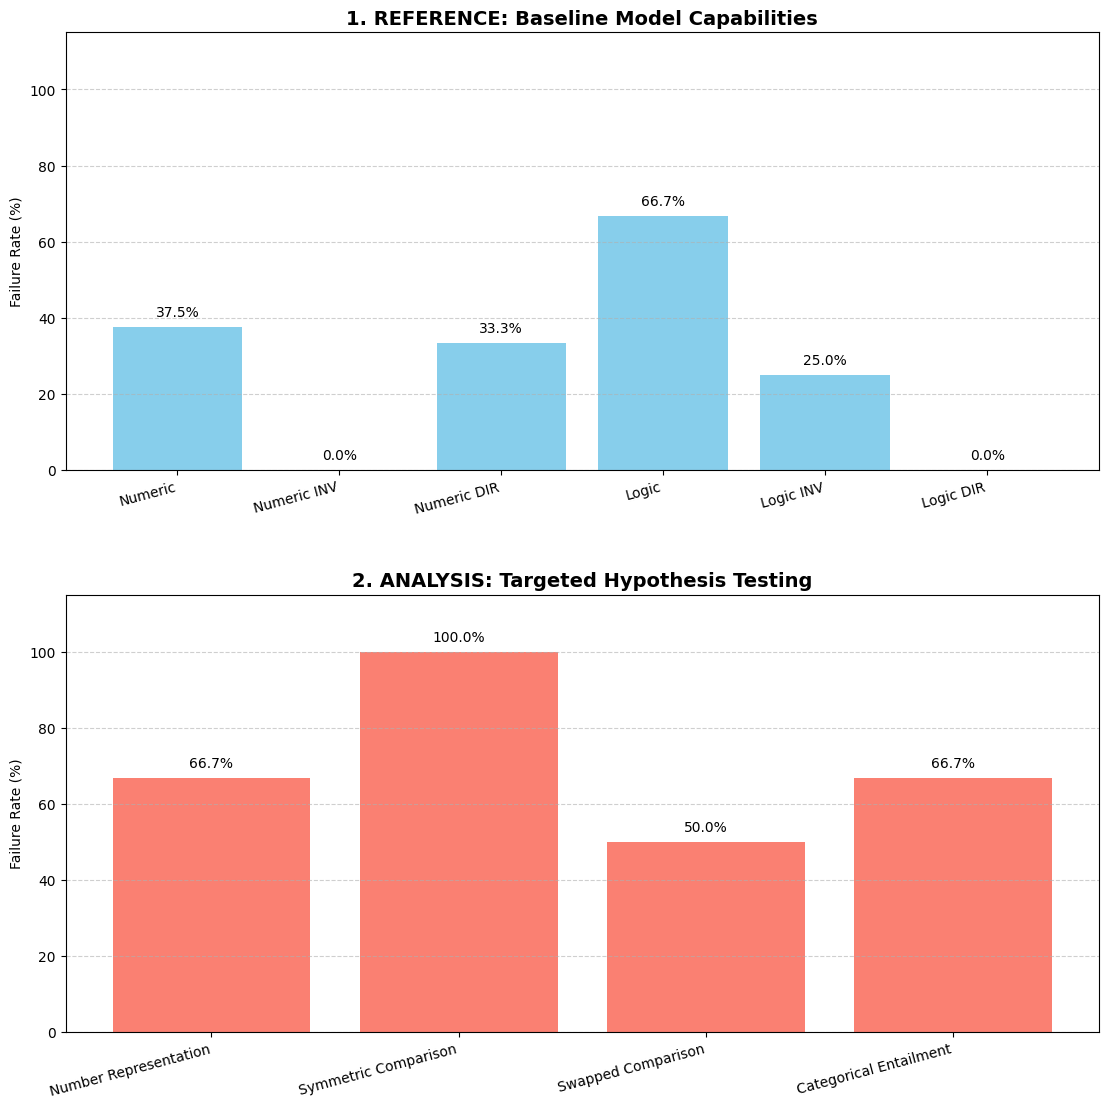

In [20]:
import matplotlib.pyplot as plt
import re

# ===========================================================
# 1. PRINT HYPOTHESES
# ===========================================================
print("="*60)
print("             HYPOTHESIS-DRIVEN EVALUATION")
print("="*60)
print("H1: Numerical Representation - Model fails to link digits (1990) to words (nineteen ninety).")
print("H2: Comparison Ordering - Model treats comparisons as Bag-of-Words (8 > 3 == 3 > 8).")
print("H3: Categorical Entailment - Model confuses subsets/supersets (Bird == Animal).")
print("="*60 + "\n")

# ===========================================================
# 2. DEFINE TARGETED TEST CASES
# ===========================================================

# H1 Cases
mft_num_representation = [
    ("I have 3 dogs.", "I have three dogs.", 1),
    ("The year 1995 was great.", "The year nineteen ninety-five was great.", 1),
    ("What happened in 1990?", "What events occurred in the year nineteen ninety?", 1)
]

# H2 Cases (Symmetry)
mft_ordering_equivalence = [
    ("Is 100 greater than 50?", "Is 50 less than 100?", 1),
    ("Is 10 greater than 5?", "Is 5 less than 10?", 1)
]

# H2 Cases (Distinctness/Swapping)
mft_ordering_distinctness = [
    ("Is 5 greater than 2?", "Is 2 greater than 5?", 0),
    ("Is 8 larger than 3?", "Is 3 larger than 8?", 0)
]

# H3 Cases
mft_entailment_asymmetry = [
    ("Are all roses flowers?", "Are all flowers roses?", 0),
    ("Are all birds animals?", "Are all animals birds?", 0),
    ("How to care for a Golden Retriever?", "How to care for a dog?", 0)
]

# ===========================================================
# 3. EXECUTE AND PRINT FAILURES
# ===========================================================

hypo_results = {
    "Number Representation": {"fails": run_mft(mft_num_representation), "total": len(mft_num_representation)},
    "Symmetric Comparison": {"fails": run_mft(mft_ordering_equivalence), "total": len(mft_ordering_equivalence)},
    "Swapped Comparison": {"fails": run_mft(mft_ordering_distinctness), "total": len(mft_ordering_distinctness)},
    "Categorical Entailment": {"fails": run_mft(mft_entailment_asymmetry), "total": len(mft_entailment_asymmetry)}
}

print("DETAILED FAILURE LOGS FOR HYPOTHESES:")
for test_name, data in hypo_results.items():
    print(f"\n--- {test_name} Failures ---")
    if not data["fails"]:
        print("None! Model passed all cases.")
    for fail in data["fails"]:
        print(f"Q1: {fail[0]}")
        print(f"Q2: {fail[1]}")
        print(f"Expected: {fail[2]}, Predicted: {1-fail[2]}")
        print("-" * 30)

# ===========================================================
# 4. VISUALIZATION
# ===========================================================

def generate_fail_chart(data_dict, title, color, subplot_pos):
    labels = list(data_dict.keys())
    # Clean up labels for baseline if they are internal keys
    display_labels = [l.replace('_', ' ').replace('MFT', '').strip() for l in labels]
    rates = [round(len(data_dict[l]["fails"]) / data_dict[l]["total"] * 100, 1) for l in labels]
    
    plt.subplot(2, 1, subplot_pos)
    bars = plt.bar(display_labels, rates, color=color)
    plt.xticks(rotation=15, ha="right")
    plt.title(title, fontweight='bold', fontsize=14)
    plt.ylabel("Failure Rate (%)")
    plt.ylim(0, 115)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2.0, yval + 2, f'{yval}%', ha='center', va='bottom')
    plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.figure(figsize=(12, 12))

# Chart 1: Baseline Reference
baseline_keys = [k for k in all_results.keys() if not k.startswith("Hypo")]
baseline_data = {k: all_results[k] for k in baseline_keys}
generate_fail_chart(baseline_data, "1. REFERENCE: Baseline Model Capabilities", "skyblue", 1)

# Chart 2: Hypothesis Results
generate_fail_chart(hypo_results, "2. ANALYSIS: Targeted Hypothesis Testing", "salmon", 2)

plt.tight_layout(pad=4.0)
plt.show()

Analysis: 

### H1: Numerical Representation - Model fails to link digits (1990) to words (nineteen ninety).
Our hypothesis was pretty spot on here. The model doesn't understand that no matter whether expressed alphabetically or numerically it represents the same thing essentially. The only case here where it doesn' fail is the case for the number 3. Presumably this occurs much more than 1995 for example, so the model might have learned the equivalence here, but does not generalize for numbers generally. 
### H2: Comparison Ordering - Model treats comparisons as Bag-of-Words (8 > 3 == 3 > 8).
For the symmetric comparison we have a 100% fail rate, the model does not seem to understand the content of a number but rather treats all sentences of is {num} bigger than {num} the same. Maybe it clusters all the numbers into a similar embedding space give that they all have the commonality "number", but it fails to understand the semantic content that the numbers hold. 
### H3: Categorical Entailment - Model confuses subsets/supersets (Bird == Animal).
Also here we see a quite high failure rate. The more obvious entailment examples it gets wrong, the one where it gets it right is where 

Maybe there is some issue underlying all of these. I think for sure how the model represents numerical numbers is very off, and it also struggles with some common sense reasoning. The tldr of this seems, this model does not seem well suited for a good QQP analysis :) 
